# Lab 7  :  Implement Random Forest algorithm

# Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('/content/data1.csv')

In [3]:
df.head()

,AGE,SEX,BMI,SP,BP,HbA1c,FPS,PPS,FAMILY H/O,ONSET AGE,DIA LIFE,SMOKING,PHY ACT,MED USE,MED ADH,nephropathy,neuropathy,retinopathy,CV,PER VAS
0,32,0,36.1,130,80,10.70,102,119,0,31,1,0,1,1,2,0,1,0,0,0
1,36,1,37.9,140,90,12.30,248,346,0,33,3,2,1,1,1,1,1,0,0,0
2,38,0,25.3,130,80,10.50,180,246,1,33,5,0,0,1,1,0,0,1,0,0
3,40,0,24.3,150,90,10.60,282,433,1,40,1,0,1,1,2,0,1,1,1,0
4,41,0,36.2,130,90,6.44,134,203,0,38,3,0,1,1,0,0,1,1,0,0


In [4]:
df.shape

(3068, 20)

In [5]:
df.columns

Index(['AGE', 'SEX', 'BMI', 'SP', 'BP', 'HbA1c', 'FPS', 'PPS', 'FAMILY H/O',
       'ONSET AGE', 'DIA LIFE', 'SMOKING', 'PHY ACT', 'MED USE', 'MED ADH',
       'nephropathy', 'neuropathy', 'retinopathy', 'CV', 'PER VAS'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3068 entries, 0 to 3067
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AGE          3068 non-null   int64  
 1   SEX          3068 non-null   int64  
 2   BMI          3068 non-null   float64
 3   SP           3068 non-null   int64  
 4   BP           3068 non-null   int64  
 5   HbA1c        3068 non-null   float64
 6   FPS          3068 non-null   int64  
 7   PPS          3068 non-null   int64  
 8   FAMILY H/O   3068 non-null   int64  
 9   ONSET AGE    3068 non-null   int64  
 10  DIA LIFE     3068 non-null   int64  
 11  SMOKING      3068 non-null   int64  
 12  PHY ACT      3068 non-null   int64  
 13  MED USE      3068 non-null   int64  
 14  MED ADH      3068 non-null   int64  
 15  nephropathy  3068 non-null   int64  
 16  neuropathy   3068 non-null   int64  
 17  retinopathy  3068 non-null   int64  
 18  CV           3068 non-null   int64  
 19  PER VA

In [7]:
df.describe()

,AGE,SEX,BMI,SP,BP,HbA1c,FPS,PPS,FAMILY H/O,ONSET AGE,DIA LIFE,SMOKING,PHY ACT,MED USE,MED ADH,nephropathy,neuropathy,retinopathy,CV,PER VAS
count,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000,3068.000000
mean,54.922751,0.510430,28.822816,139.315515,84.667536,11.130776,230.188722,334.671121,0.492177,43.138527,12.039113,1.440352,0.507823,0.511734,0.970013,0.478488,0.486310,0.504237,0.481421,0.013690
std,14.493904,0.499973,6.313811,20.007845,11.348022,2.671214,76.878657,123.538706,0.500020,12.366985,8.330187,1.128821,0.500020,0.499944,0.821785,0.499618,0.499894,0.500064,0.499736,0.116218
min,30.000000,0.000000,17.500000,90.000000,60.000000,5.400000,98.000000,119.000000,0.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.000000,0.000000,24.000000,120.000000,70.000000,8.800000,163.000000,228.750000,0.000000,34.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,29.100000,140.000000,80.000000,11.200000,232.000000,340.000000,0.000000,42.000000,10.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,67.000000,1.000000,33.925000,160.000000,90.000000,13.325000,297.000000,441.000000,1.000000,51.000000,17.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,80.000000,1.000000,40.000000,170.000000,100.000000,15.900000,365.000000,547.000000,1.000000,78.000000,33.000000,3.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Putting Feature Variable to X and Target variable to y.


In [9]:
# Putting feature variable to X
X = df.drop('AGE',axis=1)
# Putting response variable to y
y = df['AGE']

# Train-Test-Split is performed


In [11]:
# now lets split the data into train and test
from sklearn.model_selection import train_test_split
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
X_train.shape, X_test.shape

((2147, 19), (921, 19))

# Let’s import RandomForestClassifier and fit the data.


In [12]:
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=5,
                                       n_estimators=100, oob_score=True)
#%%time
classifier_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [13]:
# checking the oob score
classifier_rf.oob_score_

0.3609687936655799

## Let’s do hyperparameter tuning for Random Forest using GridSearchCV and fit the data.



In [14]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}
from sklearn.model_selection import GridSearchCV
# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="accuracy")
#%%time
grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 180 candidates, totalling 720 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [15]:
grid_search.best_score_

np.float64(0.7876165610495011)

In [16]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

## Now, let’s visualize

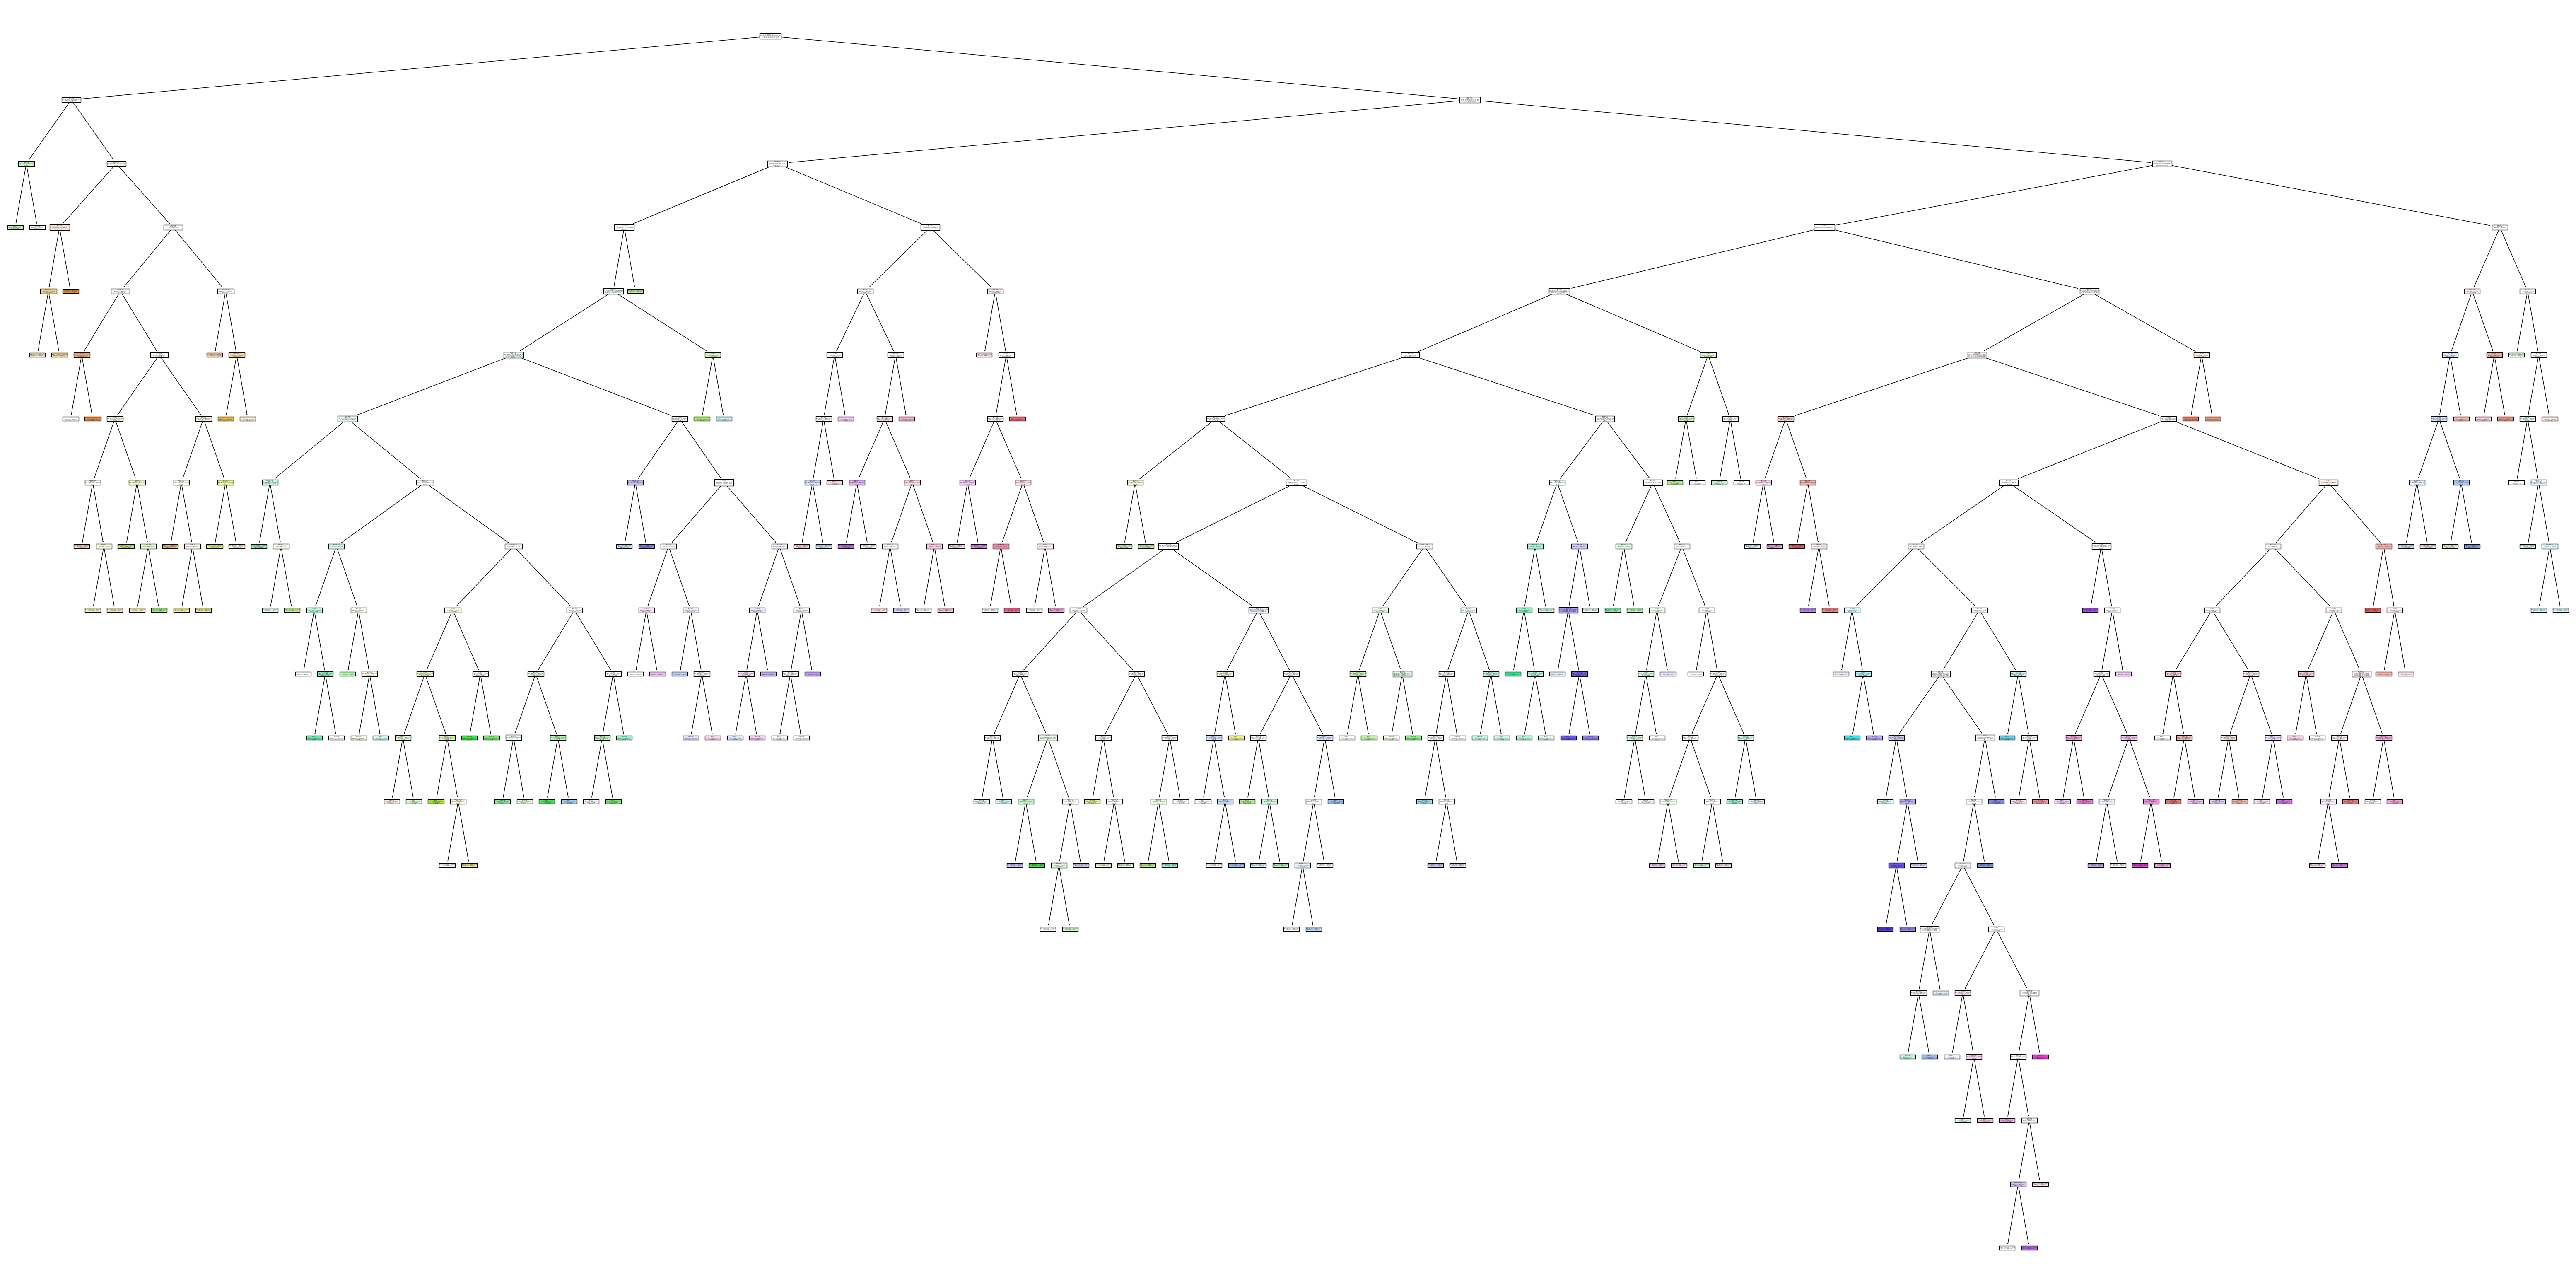

In [20]:
from sklearn.tree import plot_tree
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Make sure pandas is imported if you haven't already

# Get the unique class names from the training data and convert them to strings
# Sorting is important to ensure the order matches the internal representation
unique_class_names = np.sort(y_train.unique()).astype(str).tolist()

plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[5], feature_names = X.columns, class_names=unique_class_names, filled=True);

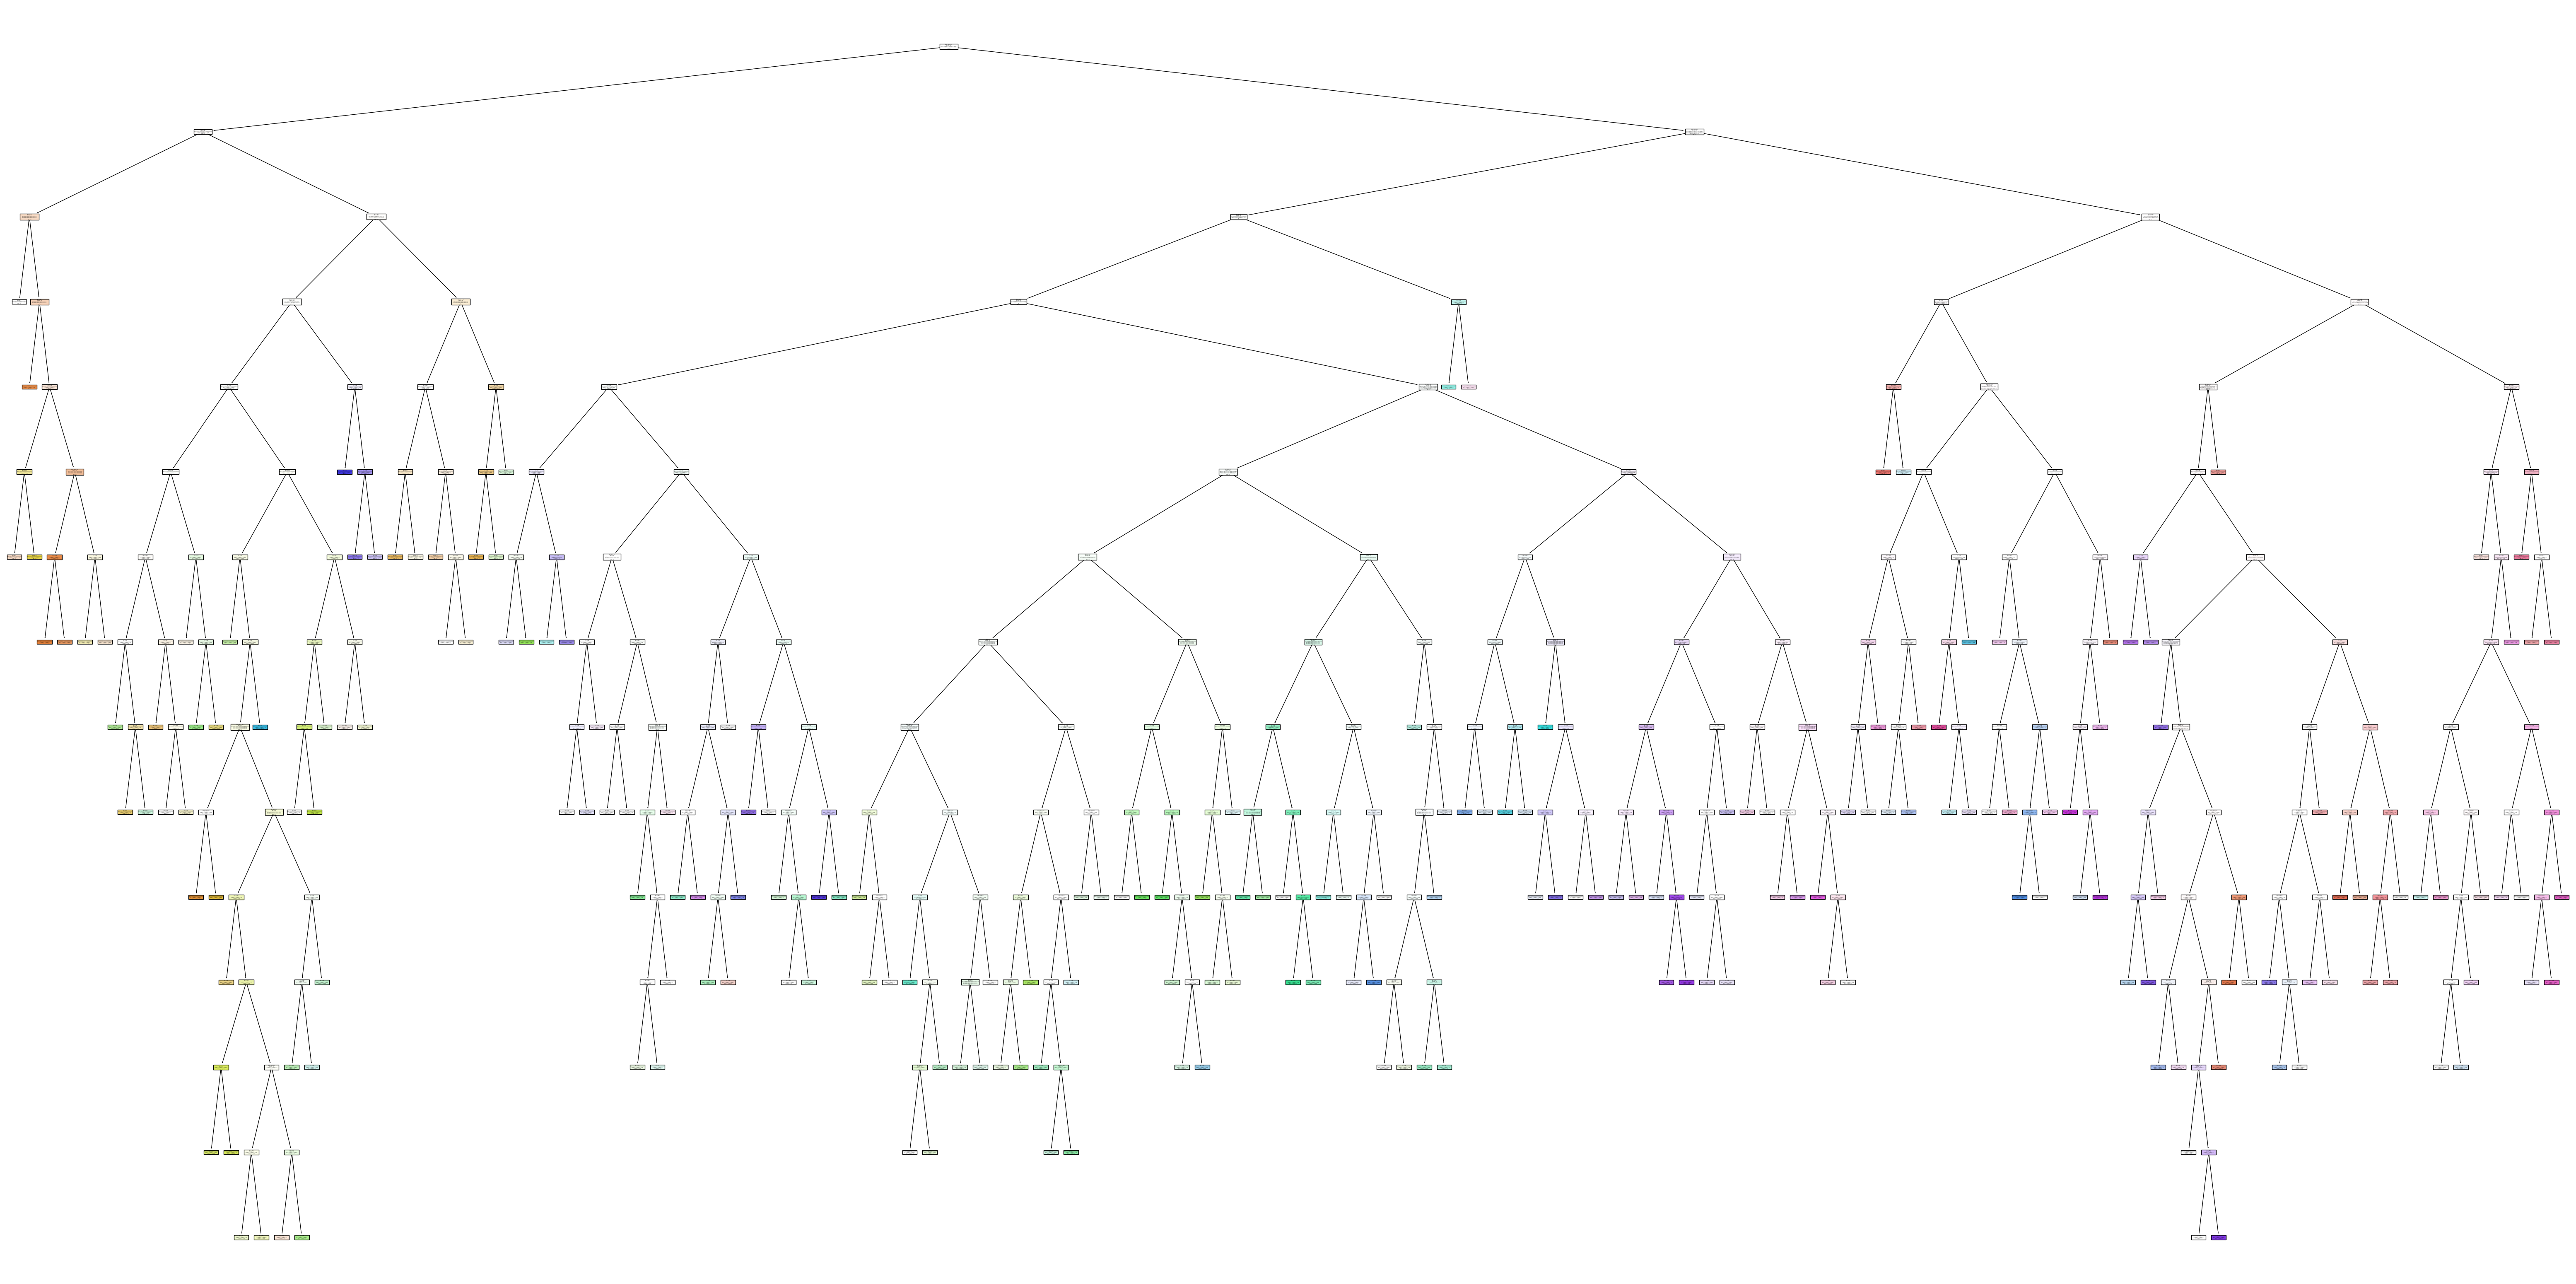

In [22]:
from sklearn.tree import plot_tree
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get the unique class names from the training data and convert them to strings
# Sorting is important to ensure the order matches the internal representation
# Use the same method as the successful plot
unique_class_names = np.sort(y_train.unique()).astype(str).tolist()

plt.figure(figsize=(80,40))
# Use the dynamically generated class names
plot_tree(rf_best.estimators_[7], feature_names = X.columns, class_names=unique_class_names, filled=True);

### The trees created by estimators_[5] and estimators_[7] are different. Thus we can say that each tree is independent of the other.

### Now let’s sort the data with the help of feature importance

In [23]:
rf_best.feature_importances_


array([0.02231066, 0.08994185, 0.0576944 , 0.03882148, 0.0868435 ,
       0.08843934, 0.0913565 , 0.01948046, 0.17709119, 0.12847666,
       0.04027594, 0.02044306, 0.0198054 , 0.03384112, 0.02186989,
       0.02092466, 0.02097894, 0.02032325, 0.00108171])

In [24]:
## feature importance

imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": rf_best.feature_importances_
})

In [25]:
imp_df.sort_values(by="Imp", ascending=False)


,Varname,Imp
8,ONSET AGE,0.177091
9,DIA LIFE,0.128477
6,PPS,0.091357
1,BMI,0.089942
5,FPS,0.088439
4,HbA1c,0.086844
2,SP,0.057694
10,SMOKING,0.040276
3,BP,0.038821
13,MED ADH,0.033841
